# Logistic regression

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [14]:
def generate_data(N, seed=42):
    rng = np.random.default_rng(seed)
    n0 = round(N * 0.53)
    n1 = N - n0
    n_left = n0 // 2
    n_mid = n0 - n_left
    left = rng.normal([-5.32, 1.05], [0.47, 0.51], size=(n_left, 2))
    mid = rng.normal([1.47, 1.06], [0.45, 0.48], size=(n_mid, 2))
    right = rng.normal([2.79, 1.01], [0.51, 0.52], size=(n1, 2))
    X = np.vstack([left, mid, right])
    y = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    idx = rng.permutation(len(X))
    return X[idx], y[idx]

# Generate data
X, y = generate_data(400)
X_train, y_train = X[:200, :], y[:200]
X_test, y_test = X[200:, :], y[200:]

In [15]:
def plot_probabilityMap(model, X, y, yh, plot_means, class_index):
    '''visualizes the output of the applied models with a probability map
    INPUT: 
        'model'-> scikit-learn like instance of classifier models with built-in method 'predict_proba' available
        'X' -> data matrix of size NxD
        'y' -> true class labels
        'yh' -> predicted class labels
        'plot_means' -> only for LDA: adding class means to the plot
        'class_index' -> probability map for class, either '0' or '1'
    
    OUTPUT:
        fig: figure handle of the plot
    '''
    fig = plt.figure(figsize=(8, 4))
    
    tp = (y == yh)  # True Positive
    tp0, tp1 = tp[y == 0], tp[y == 1]
    X0, X1 = X[y == 0], X[y == 1]
    X0_tp, X0_fp = X0[tp0, :], X0[~tp0, :]
    X1_tp, X1_fp = X1[tp1, :], X1[~tp1, :]

    # class 0: true positives vs. false positives
    plt.plot(X0_tp[:, 0], X0_tp[:, 1], 'o', color='red', label="class 0 tp")
    plt.plot(X0_fp[:, 0], X0_fp[:, 1], 'o', color='salmon', label="class 0 fp")  # dark red

    # class 1:
    plt.plot(X1_tp[:, 0], X1_tp[:, 1], 'o', color='blue', label="class 1 tp")
    plt.plot(X1_fp[:, 0], X1_fp[:, 1], 'o', color='lightskyblue', label="class 1 fp")  # dark blue

    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.legend()
    
    # class 0 and 1 : areas
    nx, ny = 200, 100
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx),
                         np.linspace(y_min, y_max, ny))
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
    Z = Z[:, class_index].reshape(xx.shape)
    plt.pcolormesh(xx, yy, Z, cmap='YlOrBr', shading='auto')
    cbar = plt.colorbar()  # colorbar assigning the probabilities
    cbar.set_label('P(class={})'.format(class_index))
        
    # plot the contour of the 50 probability
    plt.contour(xx, yy, Z, [0.5], linewidths=2., colors='k')

    # plot class means (only makes sense for LDA)
    if plot_means: 
        plt.plot(model.means_[0][0], model.means_[0][1], 'o', color='black', markersize=10)
        plt.plot(model.means_[1][0], model.means_[1][1], 'o', color='black', markersize=10)

    return fig

## Exercise 1: Inspect a logistic regression model
1. Visualize the training dataset using the class labels. 
2. Train a logistic regression model (`LogisticRegression()`) on the training data. Make sure that you use an "L2-penalty" with $C = 1$.
3. Use the trained model to predict the class labels of the test data and report on the classification performance.
4. Inspect the model with the function `plot_probabilityMap()` and visualize the probability map of class 1 of your trained model using the test dataset as an input.

Accuracy is 0.945


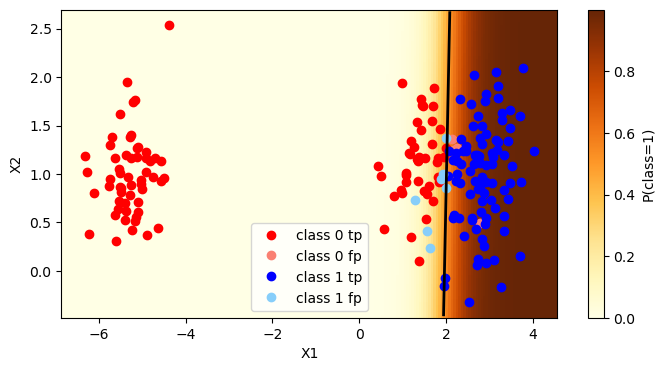

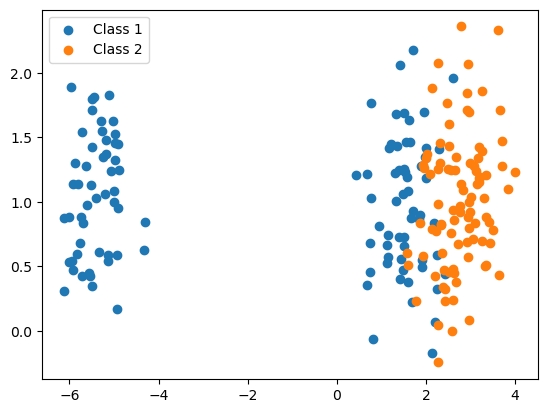

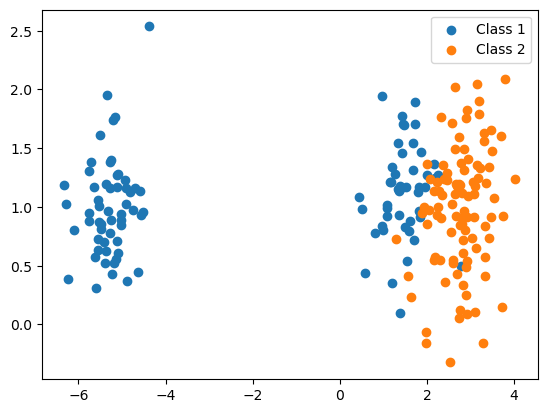

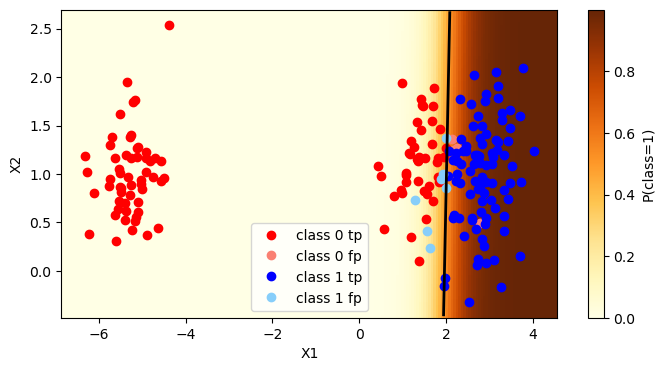

In [16]:
# Answer here
#1
plt.scatter(X_train[y_train==0,0], X_train[y_train==0,1],label='Class 1')
plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1],label='Class 2')
plt.legend()
plt.figure()
plt.scatter(X_test[y_test==0,0], X_test[y_test==0,1],label='Class 1')
plt.scatter(X_test[y_test==1,0], X_test[y_test==1,1],label='Class 2')
plt.legend()
#2
mdl = LogisticRegression(penalty='l2', C=1.0)
mdl.fit(X_train, y_train)
#3
y_hat = mdl.predict(X_test)
accuracy = sum(y_hat == y_test) / len(X_test)
print(f'Accuracy is {accuracy}')
#4
plot_probabilityMap(mdl, X_test, y_test, y_hat, plot_means=False, class_index=1)

## Exercise 2: Comparison of logistic regression with LDA 

1. Train an LDA model (`LDA()`) on the training data. Specify the solver to "eigen".
2. Use the trained LDA model to predict the class labels of the test data and report on the classification performance.
3. Apply the function `plot_probabilityMap()` to visualize the probability map of class "1" of your trained LDA model, taking the testdata set as an input. Use the input parameter of the function to visualize the class means.
4. Compare the performance of the logistic regression model with the LDA model. Do you observe a difference in the performance? Can you explain the reason? **Hint:** Compare the two decision boundaries and the assumptions made by the methods.
5. How can you estimate a probability from an LDA classifier? Remember that this is not a probabilistic method by default.

Accuracy = 0.775


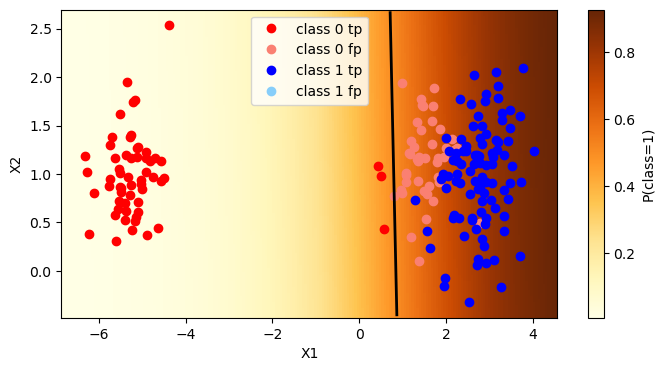

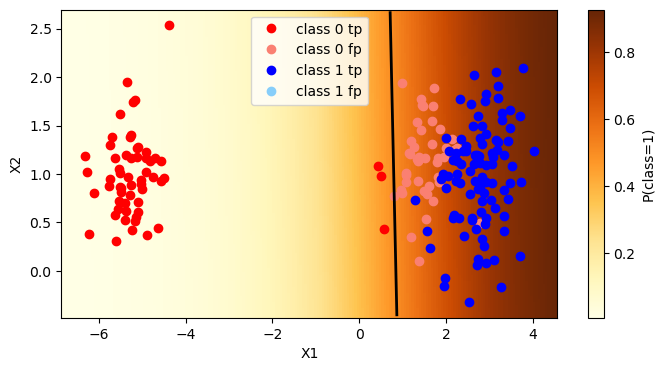

In [18]:
# Answer here
mdl2 = LDA(solver='eigen')
mdl2.fit(X_train, y_train)
y_hat2 = mdl2.predict(X_test)
accuracy2 = sum(y_hat2 == y_test) / len(y_test)
print(f'Accuracy = {accuracy2}')
plot_probabilityMap(mdl2, X_test, y_test, y_hat2, plot_means=False, class_index=1)
#4 Logistic regression outperforms LDA quite significantly. This is because LDA assumes both classes have a gaussian distribution. It fist a gaussian to both
#  classes and draws the boundary at the halfway point between the means of the two classes. But since red is bimodal and the 2 modes are far seperated,
#  the mean lies in an empty space, while all the data is distributed far away. This of course goes against the Gaussianity assumption made by LDA.
#  Logistic regression does not have any assumptions about distributions and just maps each datapoint to a the best fitted probability. Therefore it outperforms LDA in this case.
#5 The LDA output itself is not a probability. To convert to a probability we can plug it into a function that maps it to the range 0-1. Where large LDA
#  scores map to a high probability, very low negative scores map to a small probability and 0 maps to a 50% probability. To achieve this we can use the
#  sigmoid function, like this: prob=1/(1+exp(-LDA_score)).